# BB84

Alice sends random bits in random bases, Bob measures in random bases, and they keep the positions where the bases match. An eavesdropper who measures and resends pushes the error rate to about 25%. The code lives in `src/bb84.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import matplotlib.pyplot as plt

from src.bb84 import QBER_LIMIT, bb84_circuit, run

In [2]:
r = run(16, seed=3)
rows = [("Alice bit", r.alice_bits), ("Alice basis", r.alice_bases), ("Bob basis", r.bob_bases), ("Bob bit", r.bob_bits)]
for label, values in rows:
    print(f"{label:<12}", " ".join(str(v) for v in values))
print(f"{'kept':<12}", " ".join("^" if i in r.sifted else " " for i in range(16)))

Alice bit    1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0
Alice basis  1 1 0 0 0 0 1 1 0 0 1 1 0 1 1 1
Bob basis    1 0 0 1 1 1 1 0 1 0 0 1 1 0 0 0
Bob bit      1 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1
kept         ^   ^       ^     ^   ^        


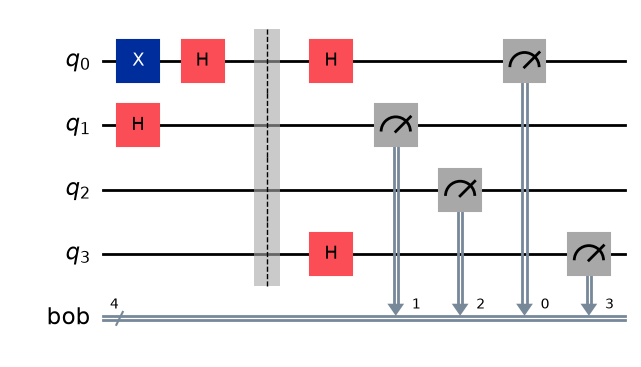

In [3]:
bb84_circuit(r.alice_bits[:4], r.alice_bases[:4], r.bob_bases[:4]).draw("mpl")

## Catching Eve

Run 200 exchanges of 256 qubits each, with and without an intercept-resend attacker, and compare the error rates Alice and Bob see in their revealed sample.

runs aborted with Eve: 199/200


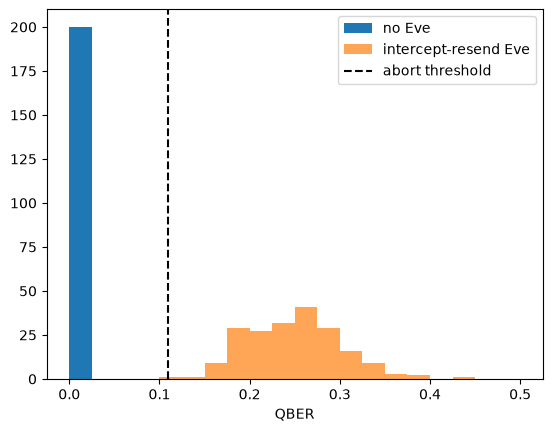

In [4]:
clean = [run(256, seed=s).qber for s in range(200)]
tapped = [run(256, eavesdrop=True, seed=s).qber for s in range(200)]

plt.hist(clean, bins=20, range=(0, 0.5), label="no Eve")
plt.hist(tapped, bins=20, range=(0, 0.5), alpha=0.7, label="intercept-resend Eve")
plt.axvline(QBER_LIMIT, color="k", linestyle="--", label="abort threshold")
plt.xlabel("QBER")
plt.legend()
print(f"runs aborted with Eve: {sum(q > QBER_LIMIT for q in tapped)}/200")